In [16]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from itertools import product
import warnings
warnings.filterwarnings('ignore')
import warnings
from sklearn.utils.parallel import Parallel
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(" Imports réussis!")

# Charger le modèle et metadata
print("\n📦 Chargement du modèle entraîné...\n")
print("=" * 60)

model = joblib.load('../models/lap_time_rf_model.pkl')
metadata = joblib.load('../models/model_metadata.pkl')

print(f"Modèle chargé:")
print(f"   - Type: {metadata['model_type']}")
print(f"   - R²: {metadata['test_r2']:.3f}")
print(f"   - MAE: {metadata['test_mae']:.2f}s")
print(f"   - Features: {len(metadata['features'])}")

# Extraire les objets nécessaires
features = metadata['features']
le_driver = metadata['label_encoder_driver']
compound_map = metadata['compound_map']

print(f"\n Metadata chargée:")
print(f"   - Pilotes disponibles: {len(le_driver.classes_)}")
print(f"   - Composés: {list(compound_map.keys())}")

print(f"\n{'=' * 60}")

 Imports réussis!

📦 Chargement du modèle entraîné...

Modèle chargé:
   - Type: RandomForestRegressor
   - R²: 0.937
   - MAE: 0.70s
   - Features: 9

 Metadata chargée:
   - Pilotes disponibles: 22
   - Composés: ['SOFT', 'MEDIUM', 'HARD']



In [17]:
# =============================================================================
# FONCTION DE PRÉDICTION DE LAP TIME
# =============================================================================

def predict_lap_time(driver, compound, tire_age, lap_number, race_baseline, 
                     total_laps=58, position=5):
    """
    Prédit le lap time pour un scénario donné
    
    Args:
        driver: Code pilote (ex: 'VER', 'NOR')
        compound: 'SOFT', 'MEDIUM', ou 'HARD'
        tire_age: Âge du pneu en tours
        lap_number: Numéro du tour actuel
        race_baseline: Temps de base du circuit (ex: 87.45s)
        total_laps: Nombre total de tours de la course (défaut: 58)
        position: Position sur piste (défaut: 5)
    
    Returns:
        Temps au tour prédit en secondes
    """
    # Encoder les inputs
    compound_encoded = compound_map[compound]
    
    try:
        driver_encoded = list(le_driver.classes_).index(driver)
    except ValueError:
        print(f"  Pilote {driver} inconnu, utilise VER")
        driver_encoded = list(le_driver.classes_).index('VER')
    
    # Calculer les features
    fuel_effect = (total_laps - lap_number) * 0.05
    is_new_tire = 1 if tire_age <= 5 else 0
    compound_tire_interaction = compound_encoded * tire_age
    tire_life_squared = tire_age ** 2
    
    # Créer le feature vector
    if 'Position' in features:
        input_data = pd.DataFrame({
            'CircuitBaseline': [race_baseline],
            'TyreLife': [tire_age],
            'TyreLifeSquared': [tire_life_squared],
            'CompoundEncoded': [compound_encoded],
            'CompoundTireInteraction': [compound_tire_interaction],
            'DriverEncoded': [driver_encoded],
            'FuelEffect': [fuel_effect],
            'IsNewTire': [is_new_tire],
            'Position': [position]
        })
    else:
        input_data = pd.DataFrame({
            'CircuitBaseline': [race_baseline],
            'TyreLife': [tire_age],
            'TyreLifeSquared': [tire_life_squared],
            'CompoundEncoded': [compound_encoded],
            'CompoundTireInteraction': [compound_tire_interaction],
            'DriverEncoded': [driver_encoded],
            'FuelEffect': [fuel_effect],
            'IsNewTire': [is_new_tire]
        })
    
    # Prédire le delta
    predicted_delta = model.predict(input_data)[0]
    
    # Convertir en temps absolu
    predicted_lap_time = race_baseline + predicted_delta
    
    return predicted_lap_time

print("✅ Fonction predict_lap_time() définie")

✅ Fonction predict_lap_time() définie


In [18]:
# =============================================================================
# RACE STRATEGY SIMULATOR
# =============================================================================

class RaceStrategySimulator:
    """
    Simulateur de stratégie de course F1
    """
    
    def __init__(self, circuit_baseline, total_laps=58, pit_stop_time=22.0):
        """
        Args:
            circuit_baseline: Temps de base du circuit (secondes)
            total_laps: Nombre total de tours
            pit_stop_time: Temps perdu au pit stop (secondes)
        """
        self.circuit_baseline = circuit_baseline
        self.total_laps = total_laps
        self.pit_stop_time = pit_stop_time
    
    def simulate_stint(self, driver, compound, stint_laps, start_lap, position=5):
        """
        Simule un stint (période entre deux pit stops)
        
        Returns:
            total_time: Temps total du stint
            lap_times: Liste des lap times
        """
        lap_times = []
        
        for tire_age in range(1, stint_laps + 1):
            current_lap = start_lap + tire_age - 1
            
            lap_time = predict_lap_time(
                driver=driver,
                compound=compound,
                tire_age=tire_age,
                lap_number=current_lap,
                race_baseline=self.circuit_baseline,
                total_laps=self.total_laps,
                position=position
            )
            
            lap_times.append(lap_time)
        
        total_time = sum(lap_times)
        return total_time, lap_times
    
    def simulate_strategy(self, driver, strategy, position=5, verbose=False):
        """
        Simule une stratégie complète de course
        
        Args:
            driver: Code pilote (ex: 'VER')
            strategy: Liste de dicts [{'compound': 'MEDIUM', 'laps': 28}, ...]
            position: Position moyenne sur piste
            verbose: Afficher les détails
        
        Returns:
            dict avec total_time, stints_detail, pit_stops
        """
        total_race_time = 0
        current_lap = 1
        stints_detail = []
        
        if verbose:
            print(f"\n{'='*70}")
            print(f" Simulation: {driver}")
            print(f"{'='*70}")
        
        for i, stint in enumerate(strategy):
            stint_time, lap_times = self.simulate_stint(
                driver=driver,
                compound=stint['compound'],
                stint_laps=stint['laps'],
                start_lap=current_lap,
                position=position
            )
            
            total_race_time += stint_time
            
            stint_info = {
                'stint_number': i + 1,
                'compound': stint['compound'],
                'laps': stint['laps'],
                'start_lap': current_lap,
                'end_lap': current_lap + stint['laps'] - 1,
                'stint_time': stint_time,
                'avg_lap_time': stint_time / stint['laps'],
                'lap_times': lap_times
            }
            stints_detail.append(stint_info)
            
            if verbose:
                print(f"\n📍 Stint {i+1}: {stint['compound']}")
                print(f"   Tours {current_lap}-{current_lap + stint['laps'] - 1} ({stint['laps']} laps)")
                print(f"   Temps stint: {stint_time:.2f}s")
                print(f"   Moyenne: {stint_time/stint['laps']:.3f}s/lap")
            
            current_lap += stint['laps']
            
            # Ajouter pit stop time (sauf après le dernier stint)
            if i < len(strategy) - 1:
                total_race_time += self.pit_stop_time
                if verbose:
                    print(f"   🔧 Pit stop: +{self.pit_stop_time:.1f}s")
        
        num_pit_stops = len(strategy) - 1
        
        if verbose:
            print(f"\n{'='*70}")
            print(f"  TEMPS TOTAL: {total_race_time:.2f}s")
            print(f"   ({total_race_time/60:.2f} minutes)")
            print(f"   Pit stops: {num_pit_stops}")
            print(f"{'='*70}")
        
        return {
            'total_time': total_race_time,
            'total_minutes': total_race_time / 60,
            'num_pit_stops': num_pit_stops,
            'stints': stints_detail,
            'avg_lap_time': total_race_time / self.total_laps
        }
    
    def compare_strategies(self, driver, strategies_dict, position=5):
        """
        Compare plusieurs stratégies
        
        Args:
            driver: Code pilote
            strategies_dict: Dict {name: strategy}
            position: Position moyenne
        
        Returns:
            DataFrame avec comparaison
        """
        results = []
        
        for name, strategy in strategies_dict.items():
            result = self.simulate_strategy(driver, strategy, position, verbose=False)
            results.append({
                'Strategy': name,
                'Total Time (s)': result['total_time'],
                'Total Time (min)': result['total_minutes'],
                'Pit Stops': result['num_pit_stops'],
                'Avg Lap (s)': result['avg_lap_time'],
                'Compounds': ' → '.join([s['compound'] for s in strategy])
            })
        
        df_results = pd.DataFrame(results).sort_values('Total Time (s)')
        
        # Ajouter delta avec le meilleur
        best_time = df_results.iloc[0]['Total Time (s)']
        df_results['Delta (s)'] = df_results['Total Time (s)'] - best_time
        
        return df_results

print(" Classe RaceStrategySimulator définie")

 Classe RaceStrategySimulator définie


In [19]:
# =============================================================================
# TEST: Simulation Abu Dhabi
# =============================================================================

print("\n Test du Simulateur - Abu Dhabi GP\n")
print("=" * 70)

# Circuit baseline (from training data)
abu_dhabi_baseline = 87.45  # Tu peux ajuster selon tes données

# Créer le simulateur
simulator = RaceStrategySimulator(
    circuit_baseline=abu_dhabi_baseline,
    total_laps=58,
    pit_stop_time=22.0
)

print(f" Simulateur créé:")
print(f"   - Circuit: Abu Dhabi")
print(f"   - Baseline: {abu_dhabi_baseline:.2f}s")
print(f"   - Total laps: 58")
print(f"   - Pit stop time: 22.0s")

# Définir des stratégies à comparer
strategies = {
    '1-stop MEDIUM→HARD (early)': [
        {'compound': 'MEDIUM', 'laps': 25},
        {'compound': 'HARD', 'laps': 33}
    ],
    '1-stop MEDIUM→HARD (late)': [
        {'compound': 'MEDIUM', 'laps': 32},
        {'compound': 'HARD', 'laps': 26}
    ],
    '1-stop SOFT→HARD': [
        {'compound': 'SOFT', 'laps': 22},
        {'compound': 'HARD', 'laps': 36}
    ],
    '2-stops SOFT→MEDIUM→HARD': [
        {'compound': 'SOFT', 'laps': 18},
        {'compound': 'MEDIUM', 'laps': 20},
        {'compound': 'HARD', 'laps': 20}
    ],
    '2-stops MEDIUM→MEDIUM→HARD': [
        {'compound': 'MEDIUM', 'laps': 20},
        {'compound': 'MEDIUM', 'laps': 20},
        {'compound': 'HARD', 'laps': 18}
    ]
}

# Comparer les stratégies
print("\n Comparaison des stratégies pour VER (Verstappen):\n")

results = simulator.compare_strategies('VER', strategies, position=1)

print(results.to_string(index=False))

print("\n" + "=" * 70)

# Identifier la meilleure
best_strategy = results.iloc[0]
print(f"\n Meilleure stratégie: {best_strategy['Strategy']}")
print(f"   Temps total: {best_strategy['Total Time (min)']:.2f} minutes")
print(f"   Composés: {best_strategy['Compounds']}")


 Test du Simulateur - Abu Dhabi GP

 Simulateur créé:
   - Circuit: Abu Dhabi
   - Baseline: 87.45s
   - Total laps: 58
   - Pit stop time: 22.0s

 Comparaison des stratégies pour VER (Verstappen):

                  Strategy  Total Time (s)  Total Time (min)  Pit Stops  Avg Lap (s)              Compounds  Delta (s)
 1-stop MEDIUM→HARD (late)     5090.930292         84.848838          1    87.774660          MEDIUM → HARD   0.000000
1-stop MEDIUM→HARD (early)     5095.608987         84.926816          1    87.855327          MEDIUM → HARD   4.678695
          1-stop SOFT→HARD     5123.790352         85.396506          1    88.341213            SOFT → HARD  32.860060
2-stops MEDIUM→MEDIUM→HARD     5161.917496         86.031958          2    88.998578 MEDIUM → MEDIUM → HARD  70.987204
  2-stops SOFT→MEDIUM→HARD     5187.024376         86.450406          2    89.431455   SOFT → MEDIUM → HARD  96.094084


 Meilleure stratégie: 1-stop MEDIUM→HARD (late)
   Temps total: 84.85 minutes
   Com


📈 Génération des visualisations...



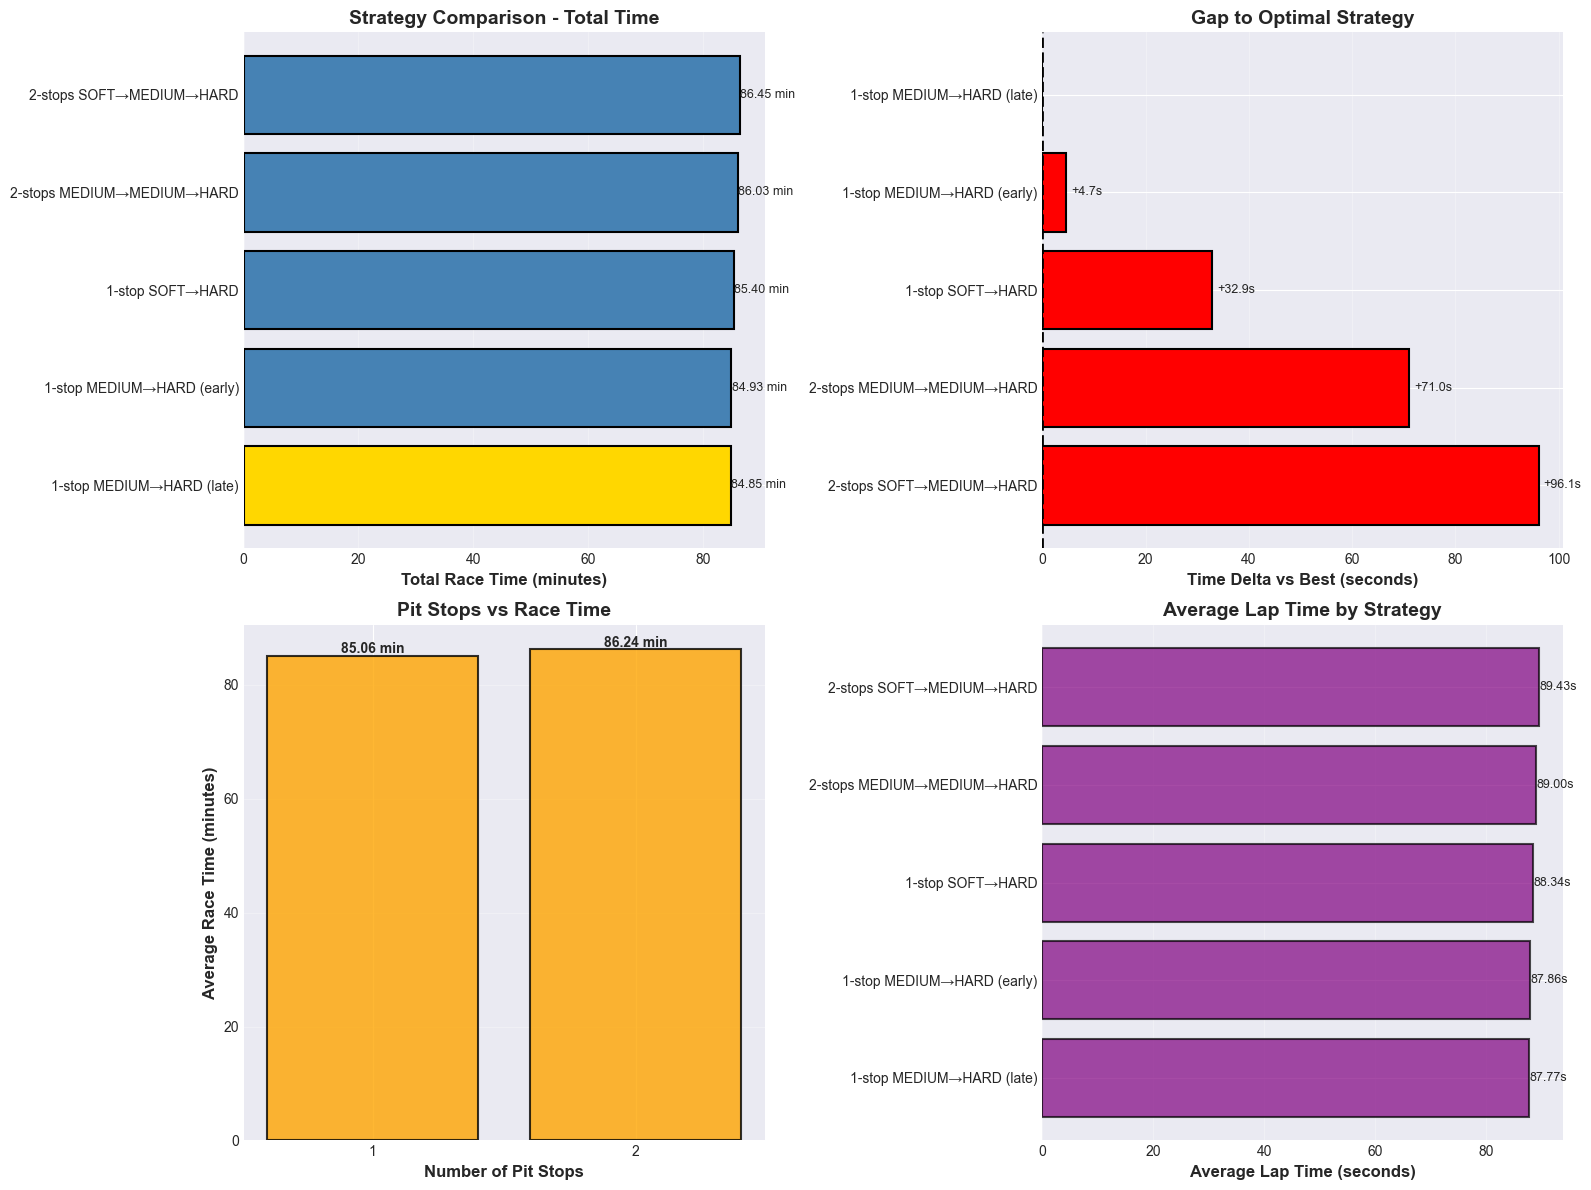

 Visualisations générées avec succès!

 Analyse des graphiques:
   - Graph 1: Compare le temps total de course
   - Graph 2: Montre l'écart avec la stratégie optimale
   - Graph 3: Impact du nombre de pit stops sur le temps
   - Graph 4: Moyenne des lap times par stratégie


In [20]:
# =============================================================================
# VISUALISATION: Comparaison des Stratégies
# =============================================================================

print("\n📈 Génération des visualisations...\n")

# Créer la figure avec 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) 

# =============================================================================
# Plot 1: Temps total par stratégie (en haut à gauche)
# =============================================================================
ax1 = axes[0, 0]

# Couleur: or pour le meilleur, bleu pour les autres
colors_plot1 = ['gold' if i == 0 else 'steelblue' for i in range(len(results))]

ax1.barh(results['Strategy'], results['Total Time (min)'], 
         color=colors_plot1, edgecolor='black', linewidth=1.5) 
ax1.set_xlabel('Total Race Time (minutes)', fontsize=12, fontweight='bold')
ax1.set_title('Strategy Comparison - Total Time', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Annoter les valeurs
for i, (idx, row) in enumerate(results.iterrows()):
    ax1.text(row['Total Time (min)'] + 0.1, i, 
             f"{row['Total Time (min)']:.2f} min", 
             va='center', fontsize=9)

# =============================================================================
# Plot 2: Delta avec le meilleur (en haut à droite)
# =============================================================================
ax2 = axes[0, 1]

results_sorted = results.sort_values('Delta (s)', ascending=False)

# Couleur: vert pour 0 delta, rouge pour le reste
colors_plot2 = []
for delta in results_sorted['Delta (s)']: 
    if delta == 0:
        colors_plot2.append('green')
    else:
        colors_plot2.append('red')

ax2.barh(results_sorted['Strategy'], results_sorted['Delta (s)'], 
         color=colors_plot2, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Time Delta vs Best (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Gap to Optimal Strategy', fontsize=14, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=2)
ax2.grid(axis='x', alpha=0.3)

# Annoter les valeurs
for i, (idx, row) in enumerate(results_sorted.iterrows()): 
    if row['Delta (s)'] > 0:
        ax2.text(row['Delta (s)'] + 1, i,  
                 f"+{row['Delta (s)']:.1f}s", 
                 va='center', fontsize=9)

# =============================================================================
# Plot 3: Nombre de pit stops (en bas à gauche)
# =============================================================================
ax3 = axes[1, 0]

pit_counts = results.groupby('Pit Stops')['Total Time (min)'].mean() 

ax3.bar(pit_counts.index.astype(str), pit_counts.values, 
        color='orange', edgecolor='black', linewidth=1.5, alpha=0.8)
ax3.set_xlabel('Number of Pit Stops', fontsize=12, fontweight='bold')
ax3.set_ylabel('Average Race Time (minutes)', fontsize=12, fontweight='bold')
ax3.set_title('Pit Stops vs Race Time', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Annoter les valeurs
for i, (pit_stop, time) in enumerate(pit_counts.items()):
    ax3.text(i, time + 0.5, f"{time:.2f} min", 
             ha='center', fontsize=10, fontweight='bold')

# =============================================================================
# Plot 4: Lap time moyen (en bas à droite)
# =============================================================================
ax4 = axes[1, 1]

ax4.barh(results['Strategy'], results['Avg Lap (s)'], 
         color='purple', edgecolor='black', linewidth=1.5, alpha=0.7)
ax4.set_xlabel('Average Lap Time (seconds)', fontsize=12, fontweight='bold')
ax4.set_title('Average Lap Time by Strategy', fontsize=14, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

# Annoter les valeurs
for i, (idx, row) in enumerate(results.iterrows()):
    ax4.text(row['Avg Lap (s)'] + 0.1, i, 
             f"{row['Avg Lap (s)']:.2f}s", 
             va='center', fontsize=9)

# Ajuster l'espacement
plt.tight_layout()
plt.show()

print(" Visualisations générées avec succès!")
print("\n Analyse des graphiques:")
print("   - Graph 1: Compare le temps total de course")
print("   - Graph 2: Montre l'écart avec la stratégie optimale")
print("   - Graph 3: Impact du nombre de pit stops sur le temps")
print("   - Graph 4: Moyenne des lap times par stratégie")

In [21]:
# =============================================================================
# PIT WINDOW OPTIMIZATION
# =============================================================================

print("\n Optimization du Pit Window\n")
print("=" * 70)

def optimize_pit_window(driver, compound_1, compound_2, circuit_baseline, 
                        total_laps=58, search_range=(15, 40), position=5):
    """
    Trouve le tour optimal pour faire le pit stop (stratégie 1-stop)
    
    Args:
        driver: Code pilote
        compound_1: Premier composé
        compound_2: Deuxième composé
        circuit_baseline: Baseline du circuit
        total_laps: Nombre total de tours
        search_range: (min, max) tours pour tester le pit
        position: Position moyenne
    
    Returns:
        dict avec résultats de l'optimization
    """
    simulator = RaceStrategySimulator(circuit_baseline, total_laps)
    
    results = []
    
    print(f" Test des pit stops entre tours {search_range[0]} et {search_range[1]}")
    print(f"   Strategy: {compound_1} → {compound_2}")
    print(f"   Driver: {driver}\n")
    
    for pit_lap in range(search_range[0], search_range[1] + 1):
        stint_1_laps = pit_lap
        stint_2_laps = total_laps - pit_lap
        
        strategy = [
            {'compound': compound_1, 'laps': stint_1_laps},
            {'compound': compound_2, 'laps': stint_2_laps}
        ]
        
        result = simulator.simulate_strategy(driver, strategy, position, verbose=False)
        
        results.append({
            'pit_lap': pit_lap,
            'stint_1_laps': stint_1_laps,
            'stint_2_laps': stint_2_laps,
            'total_time': result['total_time'],
            'total_minutes': result['total_minutes']
        })
    
    # Convertir en DataFrame
    df_results = pd.DataFrame(results)
    
    # Trouver l'optimal
    optimal = df_results.loc[df_results['total_time'].idxmin()]
    
    print(f" Pit Window Optimal:")
    print(f"   Tour: {int(optimal['pit_lap'])}")
    print(f"   Stint 1: {int(optimal['stint_1_laps'])} laps ({compound_1})")
    print(f"   Stint 2: {int(optimal['stint_2_laps'])} laps ({compound_2})")
    print(f"   Temps total: {optimal['total_minutes']:.2f} minutes")
    
    # Calculer la plage optimale (dans les 1s de l'optimal)
    time_threshold = optimal['total_time'] + 1.0
    optimal_range = df_results[df_results['total_time'] <= time_threshold]
    
    print(f"\n Plage optimale (±1s):")
    print(f"   Tours {int(optimal_range['pit_lap'].min())}-{int(optimal_range['pit_lap'].max())}")
    print(f"   Flexibilité: {len(optimal_range)} tours possibles")
    
    return df_results, optimal

# Test de l'optimization
print("Test 1: MEDIUM → HARD pour Verstappen\n")
df_opt, optimal = optimize_pit_window(
    driver='VER',
    compound_1='MEDIUM',
    compound_2='HARD',
    circuit_baseline=abu_dhabi_baseline,
    total_laps=58,
    search_range=(20, 35),
    position=1
)

print("\n" + "=" * 70)


 Optimization du Pit Window

Test 1: MEDIUM → HARD pour Verstappen

 Test des pit stops entre tours 20 et 35
   Strategy: MEDIUM → HARD
   Driver: VER

 Pit Window Optimal:
   Tour: 31
   Stint 1: 31 laps (MEDIUM)
   Stint 2: 27 laps (HARD)
   Temps total: 84.84 minutes

 Plage optimale (±1s):
   Tours 30-32
   Flexibilité: 3 tours possibles




 Visualisation du Pit Window...



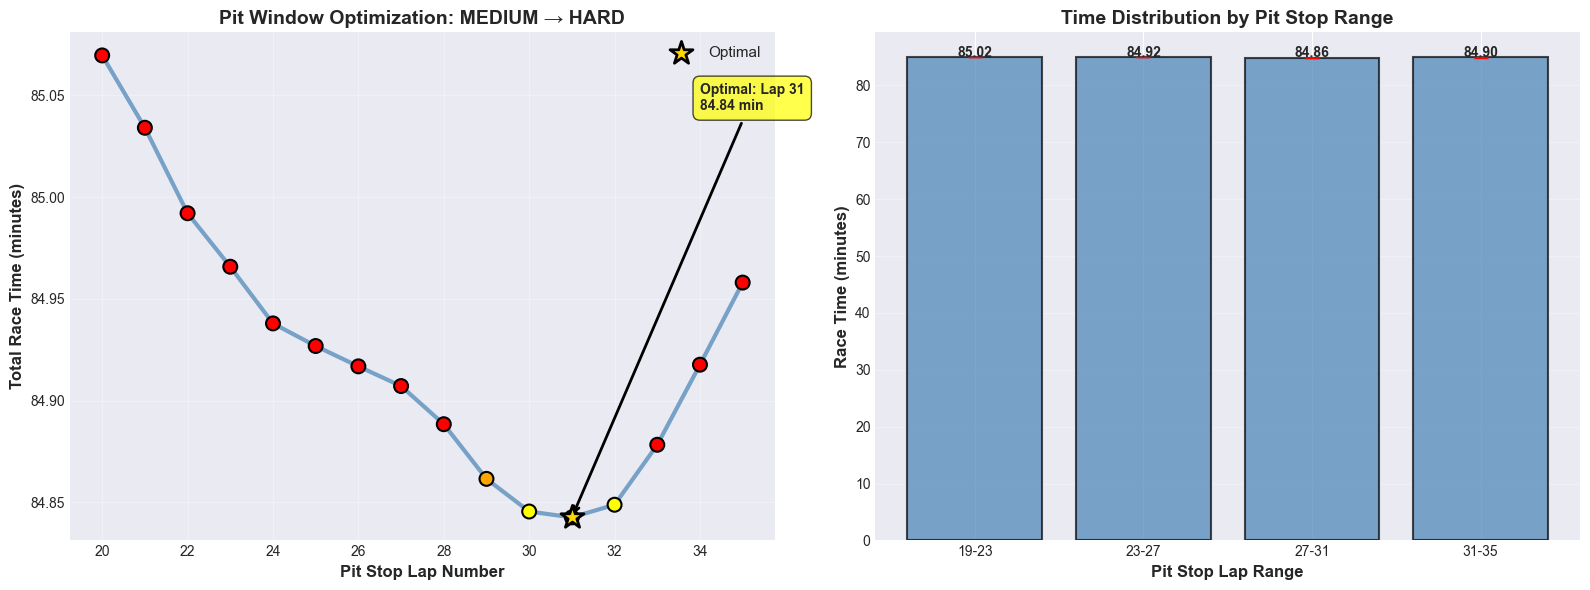

 Visualisations du pit window générées

 Insights:
   - Pit trop tôt (<25): Stint 2 trop long → dégradation
   - Pit trop tard (>30): Stint 1 trop long → dégradation
   - Sweet spot: Tours 29 à 33
   - Flexibilité stratégique: ±2 tours sans impact majeur


In [22]:
# =============================================================================
# VISUALISATION: Pit Window Analysis
# =============================================================================

print("\n Visualisation du Pit Window...\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# =============================================================================
# Plot 1: Temps total vs Tour du pit stop
# =============================================================================
ax1 = axes[0]

# Couleur: vert pour l'optimal, gradient pour les autres
colors_gradient = []
min_time = df_opt['total_time'].min()
for time in df_opt['total_time']:
    if time == min_time:
        colors_gradient.append('green')
    elif time <= min_time + 1:
        colors_gradient.append('yellow')
    elif time <= min_time + 2:
        colors_gradient.append('orange')
    else:
        colors_gradient.append('red')

ax1.plot(df_opt['pit_lap'], df_opt['total_minutes'], 
         linewidth=3, color='steelblue', alpha=0.7)
ax1.scatter(df_opt['pit_lap'], df_opt['total_minutes'], 
            c=colors_gradient, s=100, edgecolor='black', linewidth=1.5, zorder=5)

# Marquer l'optimal
optimal_idx = df_opt['total_time'].idxmin()
ax1.scatter(df_opt.loc[optimal_idx, 'pit_lap'], 
            df_opt.loc[optimal_idx, 'total_minutes'],
            s=300, marker='*', color='gold', edgecolor='black', 
            linewidth=2, zorder=10, label='Optimal')

ax1.set_xlabel('Pit Stop Lap Number', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Race Time (minutes)', fontsize=12, fontweight='bold')
ax1.set_title('Pit Window Optimization: MEDIUM → HARD', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Annoter l'optimal
ax1.annotate(f"Optimal: Lap {int(df_opt.loc[optimal_idx, 'pit_lap'])}\n"
             f"{df_opt.loc[optimal_idx, 'total_minutes']:.2f} min",
             xy=(df_opt.loc[optimal_idx, 'pit_lap'], 
                 df_opt.loc[optimal_idx, 'total_minutes']),
             xytext=(df_opt.loc[optimal_idx, 'pit_lap'] + 3, 
                     df_opt.loc[optimal_idx, 'total_minutes'] + 0.2),
             arrowprops=dict(arrowstyle='->', color='black', lw=2),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

# =============================================================================
# Plot 2: Distribution du temps par plage de pit
# =============================================================================
ax2 = axes[1]

# Diviser en bins
df_opt['pit_range'] = pd.cut(df_opt['pit_lap'], bins=4)
range_stats = df_opt.groupby('pit_range')['total_minutes'].agg(['mean', 'min', 'max'])

# Labels propres
range_labels = [f"{int(interval.left)}-{int(interval.right)}" 
                for interval in range_stats.index]

ax2.bar(range_labels, range_stats['mean'], 
        color='steelblue', edgecolor='black', linewidth=1.5, alpha=0.7)

# Ajouter min/max comme errorbars
errors = [range_stats['mean'] - range_stats['min'], 
          range_stats['max'] - range_stats['mean']]
ax2.errorbar(range_labels, range_stats['mean'], 
             yerr=errors, fmt='none', ecolor='red', capsize=5, linewidth=2)

ax2.set_xlabel('Pit Stop Lap Range', fontsize=12, fontweight='bold')
ax2.set_ylabel('Race Time (minutes)', fontsize=12, fontweight='bold')
ax2.set_title('Time Distribution by Pit Stop Range', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Annoter les valeurs
for i, (label, mean) in enumerate(zip(range_labels, range_stats['mean'])):
    ax2.text(i, mean + 0.05, f"{mean:.2f}", 
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(" Visualisations du pit window générées")

print("\n Insights:")
print(f"   - Pit trop tôt (<{int(df_opt['pit_lap'].min())+5}): Stint 2 trop long → dégradation")
print(f"   - Pit trop tard (>{int(df_opt['pit_lap'].max())-5}): Stint 1 trop long → dégradation")
print(f"   - Sweet spot: Tours {int(optimal['pit_lap'])-2} à {int(optimal['pit_lap'])+2}")
print(f"   - Flexibilité stratégique: ±2 tours sans impact majeur")

In [ ]:
# =============================================================================
# UNDERCUT SIMULATION
# =============================================================================

print("\n⚔️  Undercut Simulation\n")
print("=" * 70)

def simulate_undercut(driver_1, driver_2, undercut_laps, 
                      compound, circuit_baseline, total_laps=58):
    """
    Simule un undercut: driver_1 pit X laps avant driver_2
    
    Args:
        driver_1: Pilote qui fait l'undercut
        driver_2: Pilote qui se fait undercutter
        undercut_laps: Nombre de tours d'avance du pit
        compound: Composé utilisé par les deux
        circuit_baseline: Baseline du circuit
        total_laps: Nombre total de tours
    
    Returns:
        dict avec analyse de l'undercut
    """
    simulator = RaceStrategySimulator(circuit_baseline, total_laps)
    
    # Driver 1 pit plus tôt
    pit_lap_1 = 25
    pit_lap_2 = pit_lap_1 + undercut_laps
    
    strategy_1 = [
        {'compound': compound, 'laps': pit_lap_1},
        {'compound': 'HARD', 'laps': total_laps - pit_lap_1}
    ]
    
    strategy_2 = [
        {'compound': compound, 'laps': pit_lap_2},
        {'compound': 'HARD', 'laps': total_laps - pit_lap_2}
    ]
    
    # Simuler les deux stratégies
    result_1 = simulator.simulate_strategy(driver_1, strategy_1, position=2, verbose=False)
    result_2 = simulator.simulate_strategy(driver_2, strategy_2, position=1, verbose=False)
    
    # Calculer l'avantage de l'undercut
    # Durant les "undercut_laps", driver_1 est sur pneus neufs, driver_2 sur vieux pneus
    undercut_advantage = 0
    
    for lap in range(undercut_laps):
        # Driver 1: pneus neufs (tire_age = lap+1)
        time_1 = predict_lap_time(driver_1, 'HARD', lap+1, pit_lap_1+lap+1, 
                                   circuit_baseline, total_laps, position=2)
        
        # Driver 2: vieux pneus (tire_age = pit_lap_2 + lap)
        time_2 = predict_lap_time(driver_2, compound, pit_lap_2+lap, pit_lap_1+lap+1,
                                   circuit_baseline, total_laps, position=1)
        
        lap_advantage = time_2 - time_1
        undercut_advantage += lap_advantage
    
    print(f"🏁 Undercut Analysis:")
    print(f"\n   {driver_1} (undercut):")
    print(f"      Pit au tour: {pit_lap_1}")
    print(f"      Temps total: {result_1['total_minutes']:.2f} min")
    
    print(f"\n   {driver_2} (defend):")
    print(f"      Pit au tour: {pit_lap_2}")
    print(f"      Temps total: {result_2['total_minutes']:.2f} min")
    
    print(f"\n   💰 Undercut gain: {undercut_advantage:.2f}s sur {undercut_laps} tours")
    print(f"      ({undercut_advantage/undercut_laps:.3f}s par tour)")
    
    # Pit stop time = 22s
    # Si undercut_advantage > 22s, l'undercut est payant
    net_gain = undercut_advantage - simulator.pit_stop_time
    
    print(f"\n   🎯 Net gain (après pit stop): {net_gain:.2f}s")
    
    if net_gain > 0:
        print(f"      ✅ Undercut RÉUSSI (+{net_gain:.1f}s)")
    else:
        print(f"      ❌ Undercut ÉCHOUÉ ({net_gain:.1f}s)")
    
    return {
        'undercut_laps': undercut_laps,
        'raw_advantage': undercut_advantage,
        'net_gain': net_gain,
        'success': net_gain > 0
    }

# Test de l'undercut
print("Scénario: Verstappen undercut Norris avec 3 tours d'avance\n")

undercut_result = simulate_undercut(
    driver_1='VER',
    driver_2='NOR',
    undercut_laps=3,
    compound='MEDIUM',
    circuit_baseline=abu_dhabi_baseline
)

print("\n" + "=" * 70)

# Test de plusieurs scénarios d'undercut
print("\n📊 Test de Différents Undercut Windows:\n")

undercut_scenarios = []
for laps in range(1, 6):
    result = simulate_undercut('VER', 'NOR', laps, 'MEDIUM', abu_dhabi_baseline)
    undercut_scenarios.append(result)
    print(f"   {laps} laps d'avance: {result['net_gain']:+.2f}s → "
          f"{'✅ RÉUSSI' if result['success'] else '❌ ÉCHOUÉ'}")

print("\n" + "=" * 70)


⚔️  Undercut Simulation

Scénario: Verstappen undercut Norris avec 3 tours d'avance

🏁 Undercut Analysis:

   VER (undercut):
      Pit au tour: 25
      Temps total: 84.96 min

   NOR (defend):
      Pit au tour: 28
      Temps total: 84.92 min

   💰 Undercut gain: -20.44s sur 3 tours
      (-6.814s par tour)

   🎯 Net gain (après pit stop): -42.44s
      ❌ Undercut ÉCHOUÉ (-42.4s)


📊 Test de Différents Undercut Windows:

🏁 Undercut Analysis:

   VER (undercut):
      Pit au tour: 25
      Temps total: 84.96 min

   NOR (defend):
      Pit au tour: 26
      Temps total: 84.95 min

   💰 Undercut gain: -16.86s sur 1 tours
      (-16.858s par tour)

   🎯 Net gain (après pit stop): -38.86s
      ❌ Undercut ÉCHOUÉ (-38.9s)
   1 laps d'avance: -38.86s → ❌ ÉCHOUÉ
